<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-2/Copy_of_Project_blank_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title | House Pricing Prediction

## Problem Definition


State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.

## Data Collection/Sources


In [121]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [122]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv"
url
# Read the data straight into a DataFrame
#df = pd.read_csv(url)

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [123]:
# Read the data straight into a DataFrame
df = pd.read_csv(url)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


## Data Cleaning


In [124]:
df.shape

(2637, 81)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [126]:
df.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.637000e+03,2637.000000,2188.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2614.000000,2636.000000,...,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000
mean,7.141301e+08,57.349261,69.166819,10044.694729,6.097459,5.569966,1971.288586,1984.202882,101.887911,438.441199,...,94.305271,46.984452,22.813424,2.368601,15.775123,2.130072,42.014031,6.243838,2007.795601,179986.230186
std,1.887527e+08,42.499091,23.356779,6742.549521,1.411522,1.118262,30.306986,20.913077,179.578232,449.602326,...,126.927272,66.564333,61.177638,23.160600,55.783751,35.140140,393.158781,2.722093,1.306403,78309.251522
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7436.000000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354530e+08,50.000000,68.000000,9450.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071870e+08,70.000000,80.000000,11526.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,732.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213000.000000
max,1.007100e+09,190.000000,313.000000,164660.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,584.000000,407.000000,576.000000,800.000000,12500.000000,12.000000,2010.000000,745000.000000


In [127]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [128]:
df.tail()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000
2636,528292060,60,RL,41.0,12460,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,225000


In [129]:
df.columns.sort_values().to_list()

['1st Flr SF',
 '2nd Flr SF',
 '3Ssn Porch',
 'Alley',
 'Bedroom AbvGr',
 'Bldg Type',
 'Bsmt Cond',
 'Bsmt Exposure',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Bsmt Qual',
 'Bsmt Unf SF',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Central Air',
 'Condition 1',
 'Condition 2',
 'Electrical',
 'Enclosed Porch',
 'Exter Cond',
 'Exter Qual',
 'Exterior 1st',
 'Exterior 2nd',
 'Fence',
 'Fireplace Qu',
 'Fireplaces',
 'Foundation',
 'Full Bath',
 'Functional',
 'Garage Area',
 'Garage Cars',
 'Garage Cond',
 'Garage Finish',
 'Garage Qual',
 'Garage Type',
 'Garage Yr Blt',
 'Gr Liv Area',
 'Half Bath',
 'Heating',
 'Heating QC',
 'House Style',
 'Kitchen AbvGr',
 'Kitchen Qual',
 'Land Contour',
 'Land Slope',
 'Lot Area',
 'Lot Config',
 'Lot Frontage',
 'Lot Shape',
 'Low Qual Fin SF',
 'MS SubClass',
 'MS Zoning',
 'Mas Vnr Area',
 'Mas Vnr Type',
 'Misc Feature',
 'Misc Val',
 'Mo Sold',
 'Neighborhood',
 'Open Porch SF',
 'Overall Cond',
 'Overall Qual',

### Identify Unique IDs

In [130]:
df.nunique().sort_values()

,0
Alley,2
Street,2
Central Air,2
Land Slope,3
Bsmt Half Bath,3
Half Bath,3
Garage Finish,3
Utilities,3
Paved Drive,3
Kitchen AbvGr,4


In [131]:
df['PID']

,PID
0,905101070
1,905101330
2,903454090
3,533244030
4,909252020
...,...
2632,903231070
2633,906201021
2634,533253070
2635,527376100


### Evaluate/Explore The Target

In [132]:
# Target Variable Summary Statistics & Low-End Check

# 1. Print descriptive summary statistics for the target variable
print("--- Target Variable (SalePrice) Descriptive Statistics ---")
print(df['SalePrice'].describe())
print("-" * 57)

# 2. Check for zeros or near-zero values that could destabilize RMSPE calculations
zero_count = (df['SalePrice'] == 0).sum()
near_zero_count = (df['SalePrice'] < 100).sum()  # Practical lower threshold check

print(f"Total count of absolute zeros in SalePrice: {zero_count}")
print(f"Total count of values under $100 in SalePrice: {near_zero_count}")

# 3. Quick conditional alert if low-end values pose a division-by-zero risk
if zero_count > 0 or near_zero_count > 0:
    print("\n[WARNING]: Low or zero values detected in the target variable.")
    print("Ensure your custom RMSPE evaluation function includes a safety mask.")
else:
    print("\n[SAFE]: Target variable minimum bounds are clean for percentage error metrics.")

--- Target Variable (SalePrice) Descriptive Statistics ---
count      2637.000000
mean     179986.230186
std       78309.251522
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213000.000000
max      745000.000000
Name: SalePrice, dtype: float64
---------------------------------------------------------
Total count of absolute zeros in SalePrice: 0
Total count of values under $100 in SalePrice: 0

[SAFE]: Target variable minimum bounds are clean for percentage error metrics.


In [133]:
df['SalePrice'].isna().sum()

np.int64(0)

In [134]:
# SQRT of the rows

2637**(1/2)

51.35172830587107

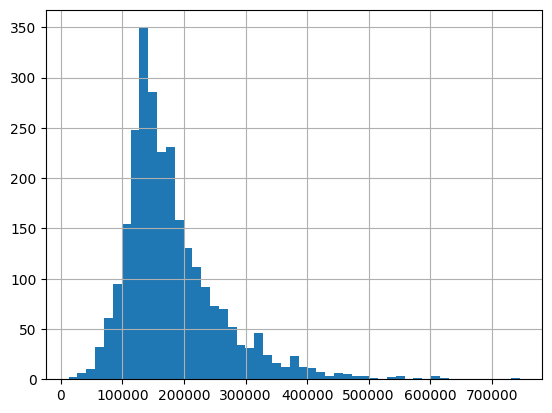

In [135]:
df['SalePrice'].hist(bins=51)

plt.show()

<Axes: >

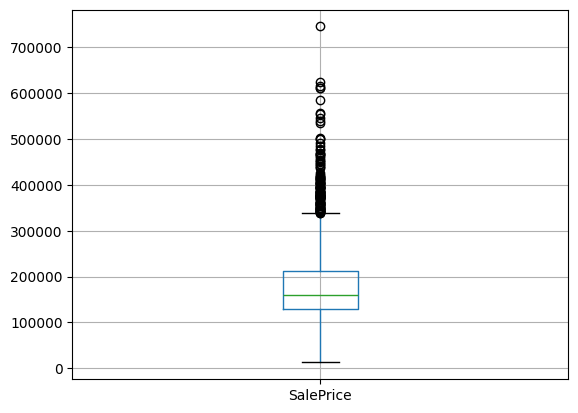

In [136]:
df[['SalePrice']].boxplot()

### Exploring Features

In [137]:
df.dtypes.value_counts()

,count
object,43
int64,27
float64,11


In [138]:
df.select_dtypes(include=['float64'])

,Lot Frontage,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath,Garage Yr Blt,Garage Cars,Garage Area
0,62.0,0.0,513.0,144.0,348.0,1005.0,1.0,0.0,1964.0,2.0,440.0
1,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1967.0,2.0,516.0
2,50.0,0.0,0.0,0.0,780.0,780.0,0.0,0.0,1979.0,1.0,544.0
3,68.0,0.0,484.0,0.0,491.0,975.0,1.0,0.0,2000.0,2.0,592.0
4,60.0,0.0,350.0,210.0,0.0,560.0,1.0,0.0,1971.0,2.0,576.0
...,...,...,...,...,...,...,...,...,...,...,...
2632,52.0,0.0,0.0,0.0,816.0,816.0,0.0,0.0,1985.0,2.0,528.0
2633,74.0,0.0,460.0,286.0,308.0,1054.0,1.0,0.0,1990.0,2.0,462.0
2634,61.0,0.0,960.0,0.0,266.0,1226.0,1.0,0.0,1981.0,2.0,484.0
2635,78.0,174.0,0.0,0.0,1064.0,1064.0,0.0,0.0,1974.0,2.0,478.0


In [139]:
df.select_dtypes(include=['int64']).columns.sort_values().tolist()

['1st Flr SF',
 '2nd Flr SF',
 '3Ssn Porch',
 'Bedroom AbvGr',
 'Enclosed Porch',
 'Fireplaces',
 'Full Bath',
 'Gr Liv Area',
 'Half Bath',
 'Kitchen AbvGr',
 'Lot Area',
 'Low Qual Fin SF',
 'MS SubClass',
 'Misc Val',
 'Mo Sold',
 'Open Porch SF',
 'Overall Cond',
 'Overall Qual',
 'PID',
 'Pool Area',
 'SalePrice',
 'Screen Porch',
 'TotRms AbvGrd',
 'Wood Deck SF',
 'Year Built',
 'Year Remod/Add',
 'Yr Sold']

In [140]:
df['Lot Area'].isna().sum()

np.int64(0)

In [141]:
pd.set_option('display.max_rows', 100)

In [142]:
df.select_dtypes(include=['int64']).isna().sum().sort_values()

,0
PID,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0


In [143]:
df_int = df.select_dtypes(include=['int64']).drop(columns=['PID', 'SalePrice'])
df_int

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,0,7,2007
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,0,500,10,2006
2,50,9000,6,6,1937,1950,780,595,0,1375,...,1,0,162,0,0,126,0,0,12,2007
3,60,7379,8,5,2000,2000,975,873,0,1848,...,1,280,184,0,0,0,0,0,4,2010
4,70,7200,7,9,1936,2007,575,560,0,1135,...,0,256,0,0,0,0,0,0,4,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,1,112,0,0,0,0,0,400,9,2006
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,0,114,36,0,0,0,0,0,7,2009
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,2,133,78,0,0,0,0,0,9,2009
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,1,0,0,0,0,0,0,0,8,2009


In [144]:
df_int.isna().sum()*1000

,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0
Gr Liv Area,0


In [145]:
df.select_dtypes(include=['int64'])

,PID,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,905101070,20,14299,4,3,1964,1964,1005,0,0,...,0,0,0,0,0,0,0,7,2007,115400
1,905101330,90,10791,4,5,1967,1967,1296,0,0,...,0,0,0,0,0,0,500,10,2006,90000
2,903454090,50,9000,6,6,1937,1950,780,595,0,...,0,162,0,0,126,0,0,12,2007,141000
3,533244030,60,7379,8,5,2000,2000,975,873,0,...,280,184,0,0,0,0,0,4,2010,254000
4,909252020,70,7200,7,9,1936,2007,575,560,0,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,6240,6,6,1934,1950,816,0,360,...,112,0,0,0,0,0,400,9,2006,114500
2633,906201021,80,10778,7,6,1990,1991,1061,0,0,...,114,36,0,0,0,0,0,7,2009,162000
2634,533253070,120,3782,8,5,1981,1981,1226,0,0,...,133,78,0,0,0,0,0,9,2009,211500
2635,527376100,20,10140,6,5,1974,1974,1350,0,0,...,0,0,0,0,0,0,0,8,2009,165000


### Exploring Object Fields

In [146]:
df.select_dtypes(include=['object'])

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,...,Detchd,Unf,TA,TA,N,NaN,MnPrv,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,...,CarPort,Unf,TA,TA,Y,NaN,NaN,Shed,WD,Normal
2,RM,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,...,Detchd,Unf,TA,TA,P,NaN,NaN,NaN,WD,Normal
3,FV,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,...,Detchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Normal
2633,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,SawyerW,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2634,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Greens,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2635,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal


In [147]:
df.select_dtypes(include=['object']).isna().sum().sort_values().divide(df.index.size)*100

,0
MS Zoning,0.000000
Street,0.000000
Lot Shape,0.000000
Land Contour,0.000000
Lot Config,0.000000
Utilities,0.000000
Land Slope,0.000000
Neighborhood,0.000000
House Style,0.000000
Condition 1,0.000000


## Exploratory Data Analysis


In [148]:
cols = ['SalePrice'] + df_int.columns.tolist()
df_lr = df[cols]
df_lr

,SalePrice,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,115400,20,14299,4,3,1964,1964,1005,0,0,...,0,0,0,0,0,0,0,0,7,2007
1,90000,90,10791,4,5,1967,1967,1296,0,0,...,0,0,0,0,0,0,0,500,10,2006
2,141000,50,9000,6,6,1937,1950,780,595,0,...,1,0,162,0,0,126,0,0,12,2007
3,254000,60,7379,8,5,2000,2000,975,873,0,...,1,280,184,0,0,0,0,0,4,2010
4,155000,70,7200,7,9,1936,2007,575,560,0,...,0,256,0,0,0,0,0,0,4,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,114500,50,6240,6,6,1934,1950,816,0,360,...,1,112,0,0,0,0,0,400,9,2006
2633,162000,80,10778,7,6,1990,1991,1061,0,0,...,0,114,36,0,0,0,0,0,7,2009
2634,211500,120,3782,8,5,1981,1981,1226,0,0,...,2,133,78,0,0,0,0,0,9,2009
2635,165000,20,10140,6,5,1974,1974,1350,0,0,...,1,0,0,0,0,0,0,0,8,2009


In [149]:
corr_matrix = df_lr.corr().abs()
corr_matrix

,SalePrice,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
SalePrice,1.000000,0.078857,0.268516,0.805016,0.095205,0.562777,0.539932,0.618247,0.268059,0.040838,...,0.468886,0.322060,0.310361,0.141685,0.040625,0.091214,0.072427,0.019955,0.052800,0.030053
MS SubClass,0.078857,1.000000,0.220406,0.046362,0.069494,0.036241,0.042770,0.249497,0.303093,0.016494,...,0.037318,0.016255,0.011079,0.027317,0.035452,0.048090,0.005281,0.016237,0.006331,0.015536
Lot Area,0.268516,0.220406,1.000000,0.095071,0.029723,0.030558,0.032820,0.347911,0.049998,0.002348,...,0.257783,0.180943,0.118606,0.017355,0.022052,0.053741,0.101980,0.053556,0.015153,0.027787
Overall Qual,0.805016,0.046362,0.095071,1.000000,0.089281,0.595225,0.571035,0.467009,0.244258,0.057611,...,0.390112,0.245627,0.295126,0.153659,0.013418,0.028213,0.026957,0.036647,0.042192,0.020052
Overall Cond,0.095205,0.069494,0.029723,0.089281,1.000000,0.359411,0.048439,0.151234,0.002867,0.004491,...,0.022691,0.030796,0.068209,0.079232,0.045597,0.053407,0.009012,0.030705,0.009906,0.042123
Year Built,0.562777,0.036241,0.030558,0.595225,0.359411,1.000000,0.614758,0.298960,0.022109,0.139847,...,0.164347,0.220759,0.186176,0.387146,0.013311,0.056855,0.010353,0.032083,0.014814,0.014875
Year Remod/Add,0.539932,0.042770,0.032820,0.571035,0.048439,0.614758,1.000000,0.236601,0.159637,0.062906,...,0.128849,0.210448,0.233864,0.231342,0.033512,0.054408,0.014081,0.034232,0.023667,0.035704
1st Flr SF,0.618247,0.249497,0.347911,0.467009,0.151234,0.298960,0.236601,1.000000,0.261955,0.018017,...,0.405815,0.208224,0.219278,0.062983,0.057126,0.086365,0.138882,0.008271,0.045737,0.009183
2nd Flr SF,0.268059,0.303093,0.049998,0.244258,0.002867,0.022109,0.159637,0.261955,1.000000,0.005746,...,0.161423,0.078973,0.199371,0.040455,0.040098,0.026043,0.032547,0.018596,0.018123,0.014703
Low Qual Fin SF,0.040838,0.016494,0.002348,0.057611,0.004491,0.139847,0.062906,0.018017,0.005746,1.000000,...,0.007203,0.006387,0.000429,0.081193,0.010167,0.012985,0.006026,0.007538,0.009026,0.002094


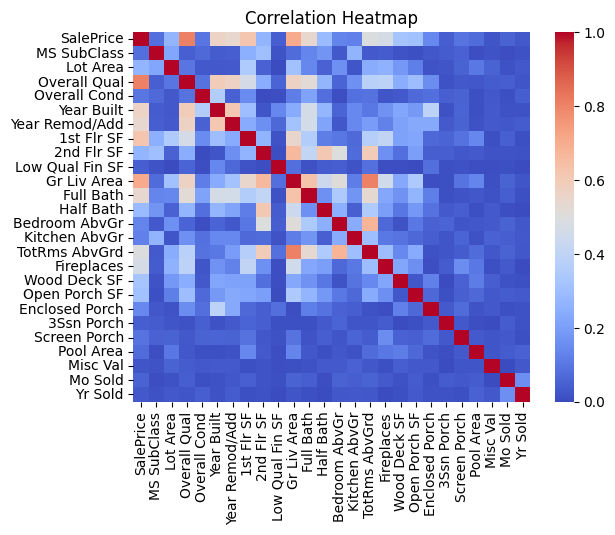

In [150]:
corr_matrix
sns.heatmap(
  corr_matrix,
  cmap='coolwarm',
  xticklabels = df_lr.columns,
  yticklabels = df_lr.columns,
  # annot=True,
  vmin = 0,
  vmax = 1,
  )

plt.title("Correlation Heatmap")
plt.savefig('corr.png')
plt.show()

## Processing



In [151]:
# PASS 1: Baseline Preprocessing & Column Isolation

# For Pass 1, I am using exactly one clean numeric feature with zero nulls
# derived from my EDA criteria (e.g., 'Gr Liv Area')

pass_1_feature = ['Gr Liv Area']

# Isolate features (X) and target (y) for our single-column baseline model
X = df[pass_1_feature]
y = df['SalePrice']

print(f"Pass 1 Baseline Feature isolated successfully: {list(X.columns)}")
print(f"Target vector shape: {y.shape}")

Pass 1 Baseline Feature isolated successfully: ['Gr Liv Area']
Target vector shape: (2637,)


In [152]:
# PASS 1: Data Splitting & Baseline Feature Scaling

# 1. Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and apply StandardScaler to scale our single feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (2109, 1)
Testing set shape: (528, 1)


In [153]:
#Fit a linear model using Sklearn

# Fit a linear model using Sklearn

def rmspe(y_true, y_pred):
    """
    Calculate Root Mean Squared Percentage Error.
    Includes a safety mask to handle potential divide-by-zero or near-zero errors.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Avoid mathematical instabilities near 0
    mask = y_true != 0
    return np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask])))

# Next line in your notebook will be:
# model1 = LinearRegression()

model = LinearRegression()

# FIX: Train using your SCALED training features
myfit = model.fit(X_train_scaled, y_train)

(myfit.intercept_, myfit.coef_)

(np.float64(179779.15315315317), array([53863.969805]))

### Residual Analysis

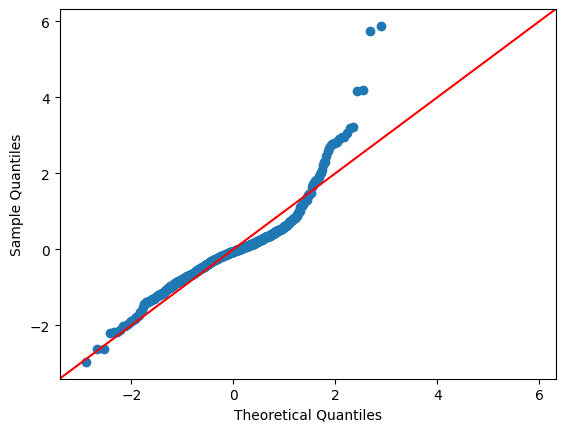

In [154]:
#QQ Plot - Residuals are normally distributed

res = y_test - y_pred

sm.qqplot(res, fit=True, line="45");

### Predictions & Error Metric Calculation

- This chunk isolates the model inferences and computes my final performance metric.

In [155]:
# 1. Predictions & Performance Evaluation

# Generate predictions using SCALED test features
y_pred = model.predict(X_test_scaled)

# Calculate the final baseline performance metric
final_rmspe = rmspe(y_test, y_pred)

print("=====================================================")
print(f"            PASS 1 BASELINE MODEL EVALUATION         ")
print("=====================================================")
print(f"Feature Used:  ['Gr Liv Area']")
print(f"Baseline RMSPE: {final_rmspe:.5f}")
print("=====================================================\n")

# Compute the baseline residuals
residuals = np.array(y_test) - y_pred

            PASS 1 BASELINE MODEL EVALUATION         
Feature Used:  ['Gr Liv Area']
Baseline RMSPE: 0.31533



### Residual Normality Diagnostic Plot

- This code block isolates my first statistical assumption check.

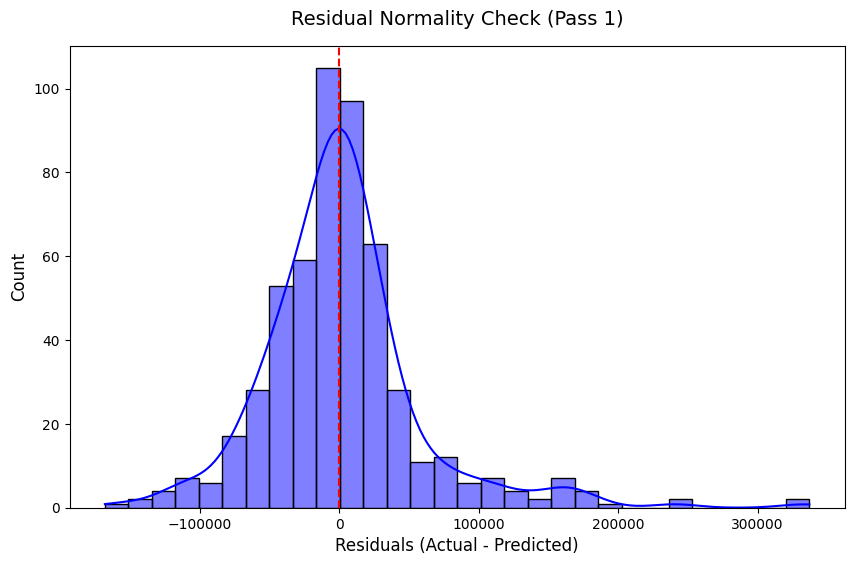

In [156]:
# 2. Residual Normality Check

plt.figure(figsize=(10, 6))

# Plot the distribution histogram with a Kernel Density Estimate line
sns.histplot(residuals, kde=True, color='blue', bins=30)

# Add an explicit midline reference at 0 error
plt.axvline(0, color='red', linestyle='--')

plt.title("Residual Normality Check (Pass 1)", fontsize=14, pad=15)
plt.xlabel("Residuals (Actual - Predicted)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

### Homoscedasticity Diagnostic Plot

- This chunk isolates the second assumption.

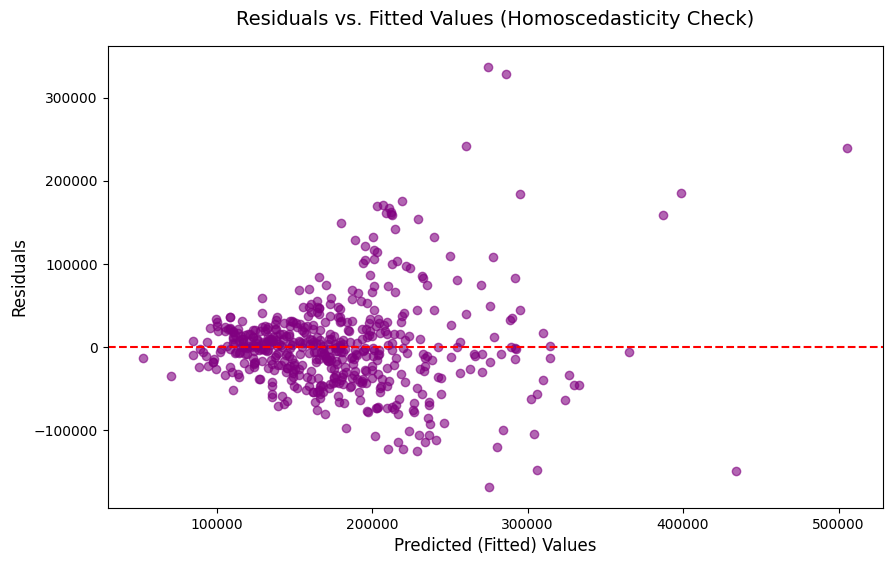

In [157]:
# 3. Residuals vs. Fitted Values Plot (Homoscedasticity)

plt.figure(figsize=(10, 6))

# Scatter plot showing error dispersion against predictions
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')

# Add an explicit zero-error horizon line
plt.axhline(0, color='red', linestyle='--')

plt.title("Residuals vs. Fitted Values (Homoscedasticity Check)", fontsize=14, pad=15)
plt.xlabel("Predicted (Fitted) Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)

plt.show()

## Data Visualization/Communication of Results


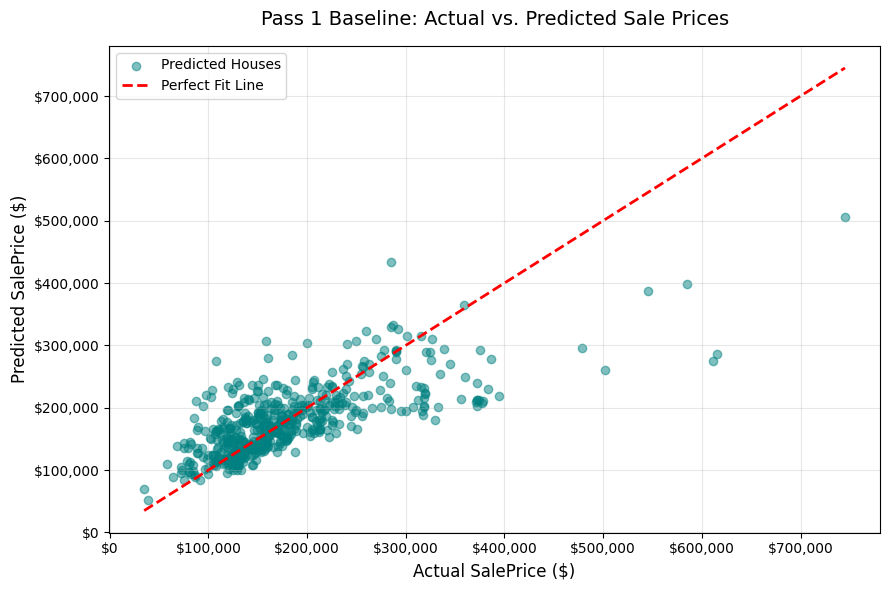

In [158]:
# PASS 1: Communication of Results - Actual vs. Predicted

plt.figure(figsize=(9, 6))

# 1. Plot the actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label='Predicted Houses')

# 2. Add the 45-degree reference line (Perfect Prediction Line)
perfect_line_range = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_line_range, perfect_line_range, color='red', linestyle='--', linewidth=2, label='Perfect Fit Line')

# 3. Labeling and Formatting
plt.title("Pass 1 Baseline: Actual vs. Predicted Sale Prices", fontsize=14, pad=15)
plt.xlabel("Actual SalePrice ($)", fontsize=12)
plt.ylabel("Predicted SalePrice ($)", fontsize=12)

# Format axes to handle standard dollar notation cleanly
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()